<a href="https://colab.research.google.com/github/ErbolTakhirov/Learning-notebooks/blob/main/statistics/statistics_lab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Калькулятор расчета вероятности для случайной величины

https://gallery.shinyapps.io/dist_calc/

# Симулятор Центральной Предельной Теоремы

https://gallery.shinyapps.io/CLT_mean/

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Before

Перед началом выполнения заданий будет полезным "поиграться" с симулятором ЦПТ.

# Task_1

Рассмотрим numpy метод `np.random.choice(arr, size)`. Он позволяет из массива случайным образом отобрать заданное количество элементов, при том что какие-то элементы могут случайно повторяться.

Дан массив `arr`. Сделайте из него случайную выборку размером 100 и сравните среднее и стандартное отклонение выборки и исходного массива. Укладывается ли выборочное среднее в 95% доверительный интервал исходной выборки?

In [ ]:
arr = np.random.normal(100, 10, 10000)

In [ ]:
size = 100
arr_ = np.random.choice(arr, size)

In [ ]:
lower_bound = arr_.mean() - arr_.std() * 1.96
upper_bound = arr_.mean() + arr_.std() * 1.96

mask = (arr_ > lower_bound) & (arr_ < upper_bound)

In [ ]:
arr_[mask].shape[0]/arr_.shape[0]

0.95

In [ ]:
se = arr_.std().item()/np.sqrt(size)

In [ ]:
se

np.float64(0.9843230124986931)

# Task_2

Дана выборка из Генеральной Совокупности, о которой мы ничего не знаем. Определите границы интервала, в котором будет находится среднее ГС с вероятностью 95%, и сохраните их в переменные
* left
* right



In [ ]:
sample = np.random.normal(20, 5, 100)

In [ ]:
sample.mean()

np.float64(20.02152493076452)

In [ ]:
n = 100
se = sample.std()/np.sqrt(n)

In [ ]:
left = sample.mean() - se*1.96

In [ ]:
right = sample.mean() + se*1.96

In [ ]:
left.round(2), right.round(2)

(np.float64(18.94), np.float64(21.1))

# Task_3

Дан набор нормально распределенных данных. Напишите функцию, которая из этого набора данных делает 100 случайных выборок заданного объема и возвращает массив со всеми выборочными средними. Функция получает 2 аргумента
* Массив
* Объем каждой выборки.

Постройте кривую распределения всех средних. Вычислите Среднее всех средних и сравните его со средним исходной выборки. Вычислите стандартное отклонение полученного массива, которое и будет являться "стандартной ошибкой среднего".

In [ ]:
arr = np.random.normal(20, 5, 10000)

In [ ]:
def sigm(arr, size):
  total = []
  for _ in range(100):
    arr_ = np.random.choice(arr, size = size)
    total.append(arr_.mean())
  return total

In [ ]:
v_arr = sigm(arr, 100)

<Axes: ylabel='Density'>

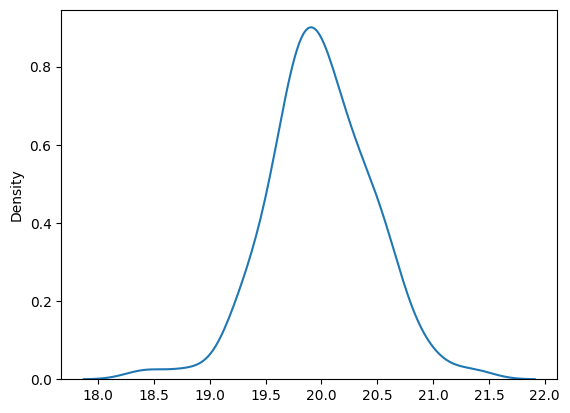

In [ ]:
sns.kdeplot(v_arr)

In [ ]:
se = np.array(v_arr).std()

In [ ]:
np.array(v_arr).mean(), arr.mean()

(np.float64(19.99074666954329), np.float64(20.00436579542468))

# Task_4

Примените написанную в предыдущем таске функцию уже к другому набору данных, распределение которого РАВНОМЕРНО. Постройте кривую распределения для всех средних и оцените его близость к нормальному.

In [ ]:
arr = np.random.uniform(20, 5, 10000)

In [ ]:
w_arr = np.array(sigm(arr, 100))

In [ ]:
arr.mean(), w_arr.mean()

(np.float64(12.573688114239884), np.float64(12.629321893984459))

<Axes: ylabel='Density'>

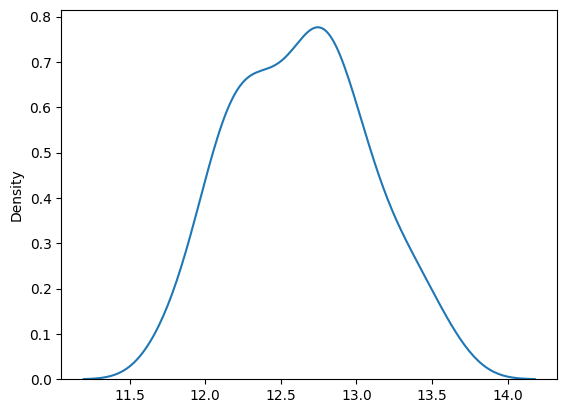

In [ ]:
sns.kdeplot(w_arr)

# Task_5

У нас онлайн продукт и нам очень важно отслеживать посещаемость нашего сайта клиентами, так как посещаемость напрямую влияет на покупки. Перед нами статистика по количеству посещений за месяц в виде массива `visits` из 1000 наблюдений. Каждый клиент - это отдельное наблюдение. Будем этот набор данных считать генеральной совокупностью, у которой:
* mean = 20
* std = 5

Мы решили провести эксперимент и проверить, повлияет ли реклама нашего продукта на посещаемость. Для этого мы отобрали контрольную группу из 100 человек и разослали им рекламу. Затем мы посчитали их посещаемость за месяц. Сформулируйте гипотезы и оцените эффективность рекламной акции.

In [ ]:
visits = np.random.normal(20, 5, 1000).round()

In [ ]:
control_group = np.array([21., 24., 25., 26., 22., 16., 27., 18., 21., 18., 18., 28., 20.,
                          24., 18., 20., 24., 24., 17., 21., 20., 26., 15., 29., 23., 22.,
                          29., 20., 21., 22., 20., 17., 19., 25., 25., 21., 26., 22., 26.,
                          20., 21., 25., 21., 20., 20., 25., 19., 22., 26., 21., 22., 26.,
                          23., 25., 21., 23., 16., 17., 22., 30., 19., 27., 25., 19., 18.,
                          19., 19., 18., 25., 14., 22., 26., 21., 21., 23., 20., 20., 25.,
                          17., 26., 30., 28., 19., 25., 23., 19., 16., 12., 16., 20., 13.,
                          18., 27., 24., 27., 16., 21., 27., 20., 27.])

In [ ]:
small = np.random.choice(control_group, 20)
m = small.mean().item()
s = small.std().item()
n = len(small)
se = s/np.sqrt(n)
m , s, n , se.item(), visits.mean().item()

(22.2, 3.655133376499413, 20, 0.817312669668102, 20.107)

In [ ]:
visits.mean()

np.float64(20.198)

In [ ]:
mean_ = control_group.mean()

In [ ]:
mean_

np.float64(21.77)

In [ ]:
control_group.std(), len(control_group)

(np.float64(3.8777699777062593), 100)

In [ ]:
se = 3.8777699777062593/10

In [ ]:
(mean_ - visits.mean())/se

np.float64(4.2885473082745404)

In [ ]:
control_group.std()

np.float64(3.8777699777062593)

In [ ]:
n = control_group.shape[0]

In [ ]:
se = visits.std()/np.sqrt(n)

In [ ]:
se

np.float64(0.5032562369211135)

In [ ]:
ses = [control_group.mean() - se*1.96, control_group.mean() + se*1.96]

In [ ]:
ses = [control_group.mean() - se*2.58, control_group.mean() + se*2.58]

In [ ]:
ses = [control_group.mean() - se*3, control_group.mean() + se*3]

In [ ]:
ses = [control_group.mean() - se*4, control_group.mean() + se*4]

In [ ]:
ses

[np.float64(20.26023128923666), np.float64(23.27976871076334)]

In [ ]:
visits.mean()

np.float64(19.854)

In [ ]:
if (visits.mean() > ses[0]) and (visits.mean() < ses[1]):
  print(True)
else:
  print(False)

False


In [ ]:
visits.mean()

np.float64(19.854)

In [ ]:
m = control_group.mean()
s = control_group.std()

n = len(control_group)
m, s, n

(np.float64(21.77), np.float64(3.8777699777062593), 100)

# Task_6

Давайте решим задачу в контексте изучения рынка земельных участков Кыргызстана. Известно, что стоимости участков в бишкеке имеют следующие статистические меры:
* mean = 37660 USD
* std = 96159 USD

Даны две выборки со стоимости участков для двух городов. Какой из этих городов c большей вероятностью является Бишкеком?

In [ ]:
city_1 = np.array([2.130180e+04, 1.431639e+05, 1.402712e+05, 1.504350e+04,
                   8.002000e+03, 2.300600e+04, 1.000000e+04, 1.398380e+04,
                    2.675420e+04, 2.000000e+03, 3.600000e+04, 3.500000e+04,
                    1.431639e+05, 2.001410e+04, 2.102220e+04, 2.501480e+04,
                    6.250300e+03, 4.120070e+04, 5.969810e+04, 2.362000e+03,
                    8.550000e+04, 1.000000e+06, 1.498960e+04, 3.531490e+04,
                    6.000000e+03, 5.386000e+03, 2.501820e+04, 1.182628e+05,
                    1.200000e+05, 1.746170e+04, 1.149950e+04, 8.562600e+03,
                    1.000000e+03, 1.424220e+04, 8.507870e+04, 2.700000e+04,
                    1.700480e+04, 1.697550e+04, 5.513400e+03, 3.599800e+03,
                    2.900000e+04, 1.193000e+02, 3.000000e+04, 4.493400e+04,
                    3.611080e+04, 1.500000e+04, 6.700000e+03, 1.662900e+03,
                    1.257840e+04, 4.481100e+03, 1.050000e+05, 6.000000e+03,
                    1.608400e+03, 8.401590e+04, 6.000000e+04, 9.882100e+03,
                    2.358500e+03, 1.473680e+04, 1.950770e+04, 6.000000e+04,
                    1.718900e+03, 3.000000e+03, 5.999280e+04, 4.412300e+03,
                    5.000000e+04, 5.191470e+04, 1.600620e+04, 2.812837e+05,
                    1.431930e+04, 1.500000e+04, 2.500000e+04, 9.041620e+04,
                    4.120100e+03, 8.215600e+03, 1.758790e+04, 3.001350e+04,
                    2.499910e+04, 7.150298e+05, 1.000000e+04, 2.099120e+04,
                    1.103150e+04, 4.000100e+04, 1.005100e+03, 4.422480e+04,
                    2.000040e+04, 5.246000e+03, 1.201230e+04, 2.700000e+03,
                    2.800000e+05, 2.004300e+04, 3.500000e+04, 2.443690e+04,
                    7.158800e+03, 1.886930e+04, 3.096000e+04, 8.403530e+04,
                    1.351000e+05, 1.200100e+03, 1.018990e+04, 1.500000e+04])

In [ ]:
city_2 = np.array([ 37088. ,   8500. ,  28260.2,   7516.1,    999.9,   3000.
                   ,40600. ,  46000. ,   2779.1,  56813.3,   1686.6,  10313.2,
                  10613.2,   7286. ,  15000. ,   1512.4,  14501.2,  94126.2,
                  46998. ,  24022.8,  19000. ,  25000. ,  15956.9,   6000.1,
                  12165.5,   5000. ,  12699.7,  37000. ,  18899.7,  29562.9,
                  9621.2,  46799.2, 265311. ,  34534.5,  20000.3,  47615.7,
                  60989.7,  25000. ,   7015.7,  20000. ,  27924.1,  22992.9,
                    429.5,  16000. ,  23732.5,  27924.1,  19986. ,   8272.3,
                  4299.9,   9396.2,  79948.1,   3507.8,  26000. ,   2965.7,
                  26556.9,  22000. ,  12999.3,  14065.1,  55349.8,   4507.1,
                  16235.6,  24175.2, 119457.2,  29390.1,   5000. ,  22000. ,
                  6280.1, 150604.6,  25048.2,   7175. ,  23003.9,   4008.6,
                  50314.5,  37000. ,  14999.9,  57500. ,  80000. ,  20002. ,
                  19703.8,  11002.6,  14000. ,  23522. ,   2514.2,   2333.7,
                  40000. ,  44999.2,  10003.9,  85000.2,  78601. ,   4000. ,
                  59878.4,  22001. ,  31399.6,  20810. ,  49955.6,   1469.3,
                  4245.4,  11999.8,  17996.6,  26521.1])

In [ ]:
def se(city):
  n = len(city)
  se = city.std().item()/np.sqrt(n)
  return [city.mean() + 1.96*se, city.mean() - 1.96*se]

In [ ]:
se1 = se(city_1)
se2 = se(city_2)

In [ ]:
se1, se2

([np.float64(76798.03352072636), np.float64(27153.842479273666)],
 [np.float64(35460.57448331246), np.float64(21715.383516687536)])

In [ ]:
b_mean = 37660
b_std = 96159

In [ ]:
def se_check(se):
  return min(se) <= b_mean <= max(se)

In [ ]:
se_check(se1)

np.True_

In [ ]:
se_check(se2)

np.False_

In [ ]:
from scipy.stats import norm, ttest_1samp, ttest_ind

In [ ]:
ttest_1samp(small, visits.mean().item())

TtestResult(statistic=np.float64(2.4959897626411816), pvalue=np.float64(0.021924932086926113), df=np.int64(19))

In [ ]:
sample1 = np.random.normal(10, 5, 100)
sample2 = np.random.normal(9, 4, 100)
# np.sqrt((sample1.std() ** 2 / 100) +(sample2.std() ** 2 / 100 ))
ttest_ind(sample1, sample2)

TtestResult(statistic=np.float64(-0.3724150937138828), pvalue=np.float64(0.7099821300175629), df=np.float64(198.0))

In [ ]:
sample1.mean(), sample1.std()

(np.float64(9.922030814562468), np.float64(5.03280523595684))

In [ ]:
np.sqrt((sample1.std() ** 2 / 100) +(sample2.std() ** 2 / 100 ))

np.float64(0.6522036965191127)

In [ ]:
ttest_ind(sample1, sample2)

TtestResult(statistic=np.float64(0.6779979991569711), pvalue=np.float64(0.4985645064472506), df=np.float64(198.0))